<a href="https://colab.research.google.com/github/Ryujeongmin-maker/Computer-Networking-Up-down/blob/main/Movie_Recommend_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!wget -c https://files.grouplens.org/datasets/movielens/ml-latest-small.zip -O movielens.zip
!unzip movielens.zip

--2025-09-23 06:19:54--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘movielens.zip’

movielens.zip       100%[===================>] 955.28K   891KB/s    in 1.1s    

2025-09-23 06:19:56 (891 KB/s) - ‘movielens.zip’ saved [978202/978202]

Archive:  movielens.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [6]:
import pandas as pd
import matplotlib.pyplot as plt   #데이터 분석에 꼭 필요한 Pandas와 시각화를 위한 Matplotlib를 불러온다.

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [7]:
# 데이터 파일 경로 설정
movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

#압축 해제한 폴더 안에 있는 movies.csv와 ratings.csv 파일을 Pandas의 **데이터프레임(DataFrame)**이라는 표 형태로 읽어옵니다.

In [8]:
# 영화 데이터 확인
print("--- 영화 데이터 (movies.csv) ---") #영화의 고유 ID, 제목, 장르 정보가 있다
display(movies.head())

# 평점 데이터 확인
print("\n--- 평점 데이터 (ratings.csv) ---") #사용자의 고유 ID, 어떤 영화, 점수에 대한 정보가 있다
display(ratings.head())

#head()함수는 데이터의 첫 5줄을 보여준다.

--- 영화 데이터 (movies.csv) ---


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



--- 평점 데이터 (ratings.csv) ---


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


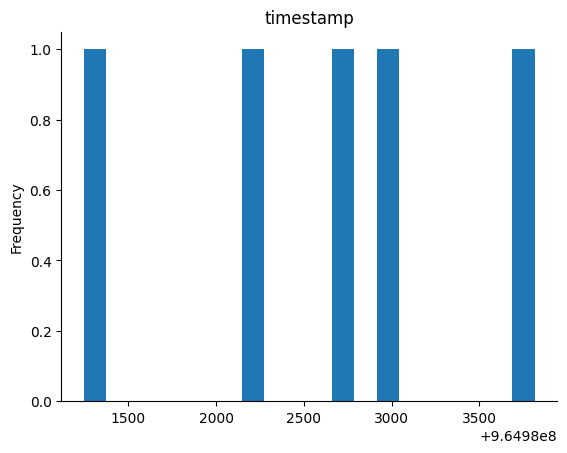

In [5]:
from matplotlib import pyplot as plt
_df_2['timestamp'].plot(kind='hist', bins=20, title='timestamp')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [6]:
print("--- 영화 데이터 정보 ---")
movies.info()

print("\n\n--- 평점 데이터 정보 ---")
ratings.info()

print("\n\n--- 평점 데이터 통계 ---")
display(ratings.describe())

--- 영화 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


--- 평점 데이터 정보 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


--- 평점 데이터 통계 ---


,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


In [18]:
#데이터전처리
from sklearn.model_selection import train_test_split
#데이터를 훈련용과 실험용으로 나누어주는 도구
from sklearn.preprocessing import LabelEncoder
#문자와 숫자가 섞인 데이터를 모델이 이해할 수 있도록 0부터 시작하는 고유한 숫자로 바꿔주는(인코딩)도구,
import tensorflow as tf
#Google에서 만든 딥러닝 프레임워크. 가장 핵심적인 라이브러리
from tensorflow.keras.models import Model
#tensorflow에서 모델 설계도를 가져옴.
from tensorflow.keras.layers import Input, Embedding, Flatten, Dot
#Input(데이터 입구), Embedding(ID를 잠재요인 벡터로 전환), Flatten(데이터를 1차원화),#Dot(두 벡터를 곱해서 최종결과값을 예측)
from tensorflow.keras.optimizers import Adam
#최적화 도구

ratings_df = ratings.copy() #원본 데이터(ratings)를 보존하기 위해 데이터프레임을 복사, 혹시 모를 실수에 대비

user_encoder = LabelEncoder() #사용자 ID와 영화 ID를 0부터 시작하는 숫자로 바꿈, 모델이 각 사용자와 영화를 하나의 카테고리로 인식하게 함
movie_encoder = LabelEncoder()

ratings_df['user_id_encoded'] = user_encoder.fit_transform(ratings_df['userId']) #user_encoder , movie_encoder은 각각 사용자용, 영화용 번호 부여도구
ratings_df['movie_id_encoded'] = movie_encoder.fit_transform(ratings_df['movieId'])

num_users = len(ratings_df['user_id_encoded'].unique()) #사용자와 영화가 각각 몇개인지 숫자를 센다. 임베딩 레이어의 크기를 정해주기 위해 필요한 과정
num_movies = len(ratings_df['movie_id_encoded'].unique())

print(f"총 사용자 수: {num_users}")
print(f"총 영화 수: {num_movies}")

x = ratings_df[['user_id_encoded', 'movie_id_encoded']] #데이터를 문제지(x)와 정답지(y)로 나눈다. ex)모델에게 [사용자,영화]를 문제지라 하고 [평점]을 정답지라고 학습시킴.
y = ratings_df['rating']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42) #x_train, y_train = 훈련용(80%) x_test , y_test(20%),
                                                                                           #random_state=42는 데이터를 나눌때 항상 똑같은 방식으로 섞고 나누는 옵션으로 일관성을 유지한다.

총 사용자 수: 610
총 영화 수: 9724


In [19]:
from os import name
##딥러닝 모델 설계하기

embedding_dim = 80 #잠재 요인의 차원 수를 80으로 설정

user_input = Input(shape=(1,), name='user input')  #input : 데이터가 들어오는 입구
movie_input = Input(shape=(1,), name = 'movie input')

user_embedding = Embedding(input_dim=num_users, output_dim=embedding_dim,name='user_embedding')(user_input) #임베딩 레이어로 모델의 가장 중요한 부분.
movie_embedding = Embedding(input_dim=num_movies, output_dim=embedding_dim, name='movie_embedding')(movie_input)
#LabelEncoder로 만들었던 단순한 번호표를(0,1,2 ...) 의미를 가진 80차원의 특정 벡터로 변환해준다. 이 과정에서 모델은 스스로 사용자의 취향과 영화특징을 학습함.

user_vec = Flatten(name = 'flatten_user')(user_embedding) #벡터 평탄화
movie_vec = Flatten(name = 'flatten_movie')(movie_embedding)
#임베딩 과정을 거친 데이터는 2차원 형태인데, 이를 계산하기 쉽도록 1차원으로 펴주는 과정

dot_product = Dot(axes=1, name='dot_product')([user_vec, movie_vec]) #벡터 내적 : 사용자의 특징 벡터와 영화의 특징 벡터를 곱한다. 이 결과가 곧 예상 평점이됨.

model = Model(inputs=[user_input, movie_input], outputs = dot_product) #입력과 출력을 정의

model.compile(optimizer=Adam(learning_rate = 0.001), loss = 'mean_squared_error') #loss와 최적화 방법 설정

model.summary #전체 구조를 출력

<bound method Model.summary of <Functional name=functional_1, built=True>>

Epoch 1/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 11.4956 - val_loss: 2.4058
Epoch 2/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.7106 - val_loss: 1.4669
Epoch 3/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.9531 - val_loss: 1.3251
Epoch 4/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.7013 - val_loss: 1.2786
Epoch 5/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.5463 - val_loss: 1.2648
Epoch 6/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.4300 - val_loss: 1.2685
Epoch 7/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.3325 - val_loss: 1.2756
Epoch 8/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.2596 - val_loss: 1.2872
Epoch 9/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.1992 - val_loss: 1.2996
Epoch 10/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.1518 - val_loss: 1.3128


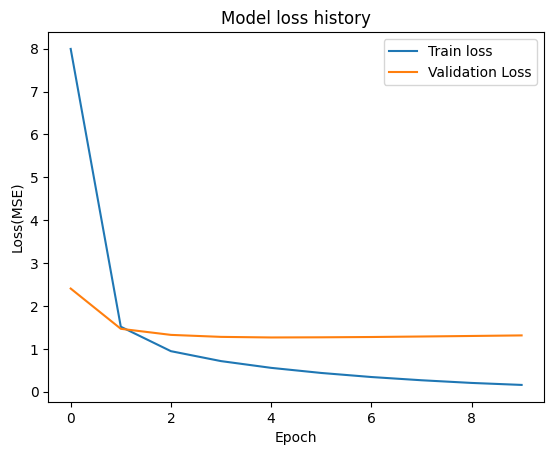

In [20]:
#모델 학습을 시작
history = model.fit(
    [x_train['user_id_encoded'], x_train['movie_id_encoded']], y_train,
    epochs = 10, #전체 훈련 데이터를 10번 반복학습하라는 명령어
    verbose = 1, #애니메이션 진행 막대를 보여라
    validation_data = ([x_test['user_id_encoded'], x_test['movie_id_encoded']], y_test) #epoch가 1회 끝날때마다 모델이 한번도 본 적없는 데이터로 시험을 봄 ==> 모델이 답을 쌩으로 외우는지, 일반화를 시키고 있는지를 확인할 수 있음
)

plt.plot(history.history['loss'], label='Train loss') #Train loss = 훈련손실, 오차. 학습이 진행될수록 감소한다.
plt.plot(history.history['val_loss'], label = 'Validation Loss') #Validation Loss = 검증손실, 이 값이 낮을 수록 모델의 실제 성능이 뛰어나다.
plt.title('Model loss history')
plt.ylabel('Loss(MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()